Gotta make some tuning curves for homings. 
Two types of plots:
- tuning curves, by condition sorted for that condition and the sorting applied to the other two conditions
- scatter of peak firing of each neuron across conditions

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

#JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# 
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

#
trials = [[1,3],[1,5,7],[1],[2],
    [2,3],[1,3],
    [1,3,4],[1,2,3],[1,2],[1,3],
    [4,5],[1,3],[3,4],[4,5],[2,5],
    [1,3],[1,2],[1,3],[5,7,8],[3,5],
]

In [ ]:
%load_ext autoreload
from JR_test_scripts.escape.escape_utils import load, load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods, extract_non_homing_escape_periods
from JR_test_scripts.escape.escape_plotting_funcs import tuning_curve_by_condition, plot_pref_firing_condition, plot_tuning_matrix, tuning_curve_compare, xval_compare
from JR_test_scripts.escape.escape_tuning_funcs import neuron_tuning_by_var, compute_r_squared, single_trial_tuning

import numpy as np

In [ ]:
"""Make plots for the neurons using their tuning curves for sorting. Plot only neurons with xval tuning curves or all neurons"""

%autoreload 2
compression_var = ['y_pos', 'distance_shelter', 'escape','speed']
for i, exp in enumerate(experiments_objects[13:]):
    # load data
    session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    ons, offs, homie = load_homing(session, len(behave))
    for comp in compression_var:
        
        nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
        var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, return_escape = True)
        
        # eliminate neurons that are all NaN (they probably didn't fire at all during homing/escape)
        bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
        escape_matrix = escape_matrix[~bad_neurons,:]

2025-01-06 16:06:45.946 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:08:20.255 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:10:27.589 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:12:25.616 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:14:13.988 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:15:59.832 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:17:35.439 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [ ]:
from JR_test_scripts.escape.escape_tuning_funcs import create_xval_tuning_curve 
exp = experiments_objects[7]
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
comp = 'distance_shelter'
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, no_stationary = False, return_escape = True)
bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
peak_firing_condition, tuning, xval = neuron_tuning_by_var(var, escape_matrix, cond, h_start)
mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)

smooth data before gaussian fitting?
fit two peak gaussian?
plot the individual trials for each cell to see that it is consistent in its firing at each position

In [ ]:
"""Make a matrix for each neuron of activity per bin on each trial"""
from JR_test_scripts.escape.escape_utils import firing_by_bin

def single_trial_tuning(escape_matrix, var, cond, h_start):
    """Make a matrix for each neuron of activity per bin on each trial
    INPUT: 
        escape_matrix: is neurons x time (firing rates)
        esc_var: is in time, the behavioral variable of interest (discretized)
        cond: a vector of length time indicating what experimental condition the homing/escape was in
        h_start: the start time of the homings or escapes, duration of homing/escape is cropped to when the mouse reaches shelter
        """
    mat_by_cond = []
    # iterate through conditions
    for i in np.unique(cond):
        # start by condition
        cond_start = [x for x in h_start if cond[x] == i]
        cond_start.append(np.sum(cond == i))
        # initialize variable, neurons x trials x bins
        bins = int(np.amax(var)+1)
        mat = np.zeros((np.shape(escape_matrix)[0],len(cond_start),bins))
        # iterate through neurons
        for j, n in enumerate(escape_matrix):
            # iterate through trials, pull out firing by bin
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                mat[j, tr,:] = firing_by_bin(v.astype(int), neur, bins, remove_empty = False)
        mat_by_cond.append(mat)
    return mat_by_cond

In [26]:
def compute_r_squared(y_observed, y_predicted):
    ss_res = np.sum((y_observed - y_predicted) ** 2)
    ss_tot = np.sum((y_observed - np.mean(y_observed)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared

(array([15., 12., 32., 33., 19., 11., 12.,  8.,  3.,  6.]),
 array([-1.70567692, -1.43653298, -1.16738905, -0.89824512, -0.62910119,
        -0.35995725, -0.09081332,  0.17833061,  0.44747455,  0.71661848,
         0.98576241]),
 <BarContainer object of 10 artists>)

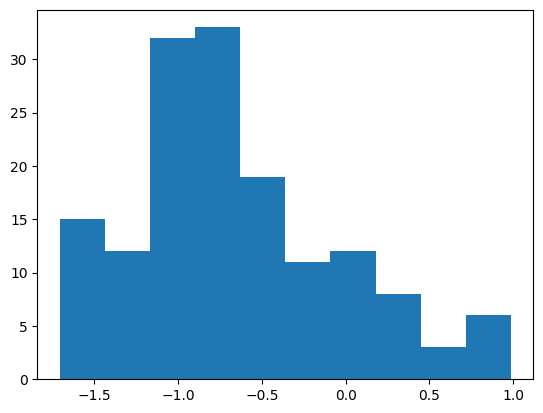

In [37]:
firing_rates  = test[neuron,:]
plt.hist(firing_rates + np.amin(firing_rates), bins = 10)

Fitted parameters: A = 1.43, mu = 68.00, sigma = 108.81
Couldn't fit double gaussian


Text(0, 0.5, 'Trials')

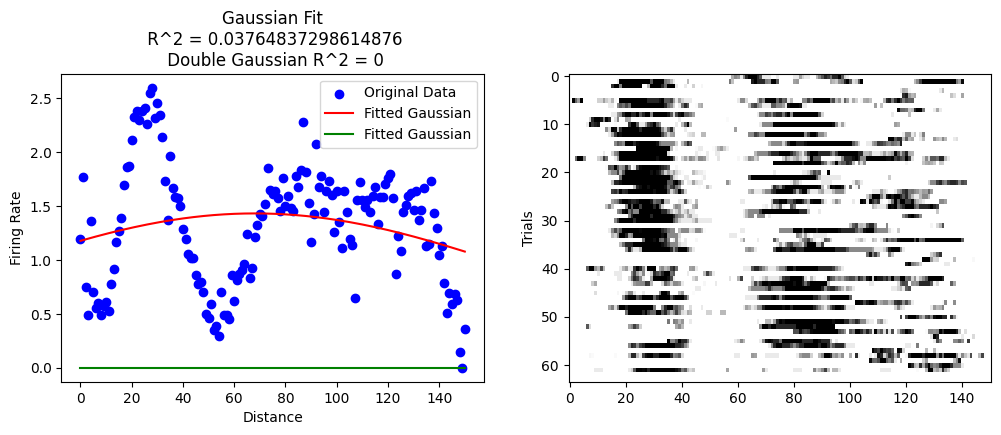

In [46]:
condition = 2
neuron = 3
xval_true = 1
test = tuning[condition][xval[:,condition] == xval_true,:]
firing_rates  = test[neuron,:]
firing_rates = firing_rates + abs(np.amin(firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
distances = np.arange(len(firing_rates))
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Define double Gaussian function
def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    gaussian1 = A1 * np.exp(-((x - mu1) ** 2) / (2 * sigma1 ** 2))
    gaussian2 = A2 * np.exp(-((x - mu2) ** 2) / (2 * sigma2 ** 2))
    return gaussian1 + gaussian2

# Fit Gaussian to the data
initial_guess = [max(firing_rates), distances[np.argmax(firing_rates)], np.std(distances)]  # Initial guesses for A, mu, sigma
params, covariance = curve_fit(gaussian, distances, firing_rates, p0=initial_guess)

# Extract parameters
A, mu, sigma = params
print(f"Fitted parameters: A = {A:.2f}, mu = {mu:.2f}, sigma = {sigma:.2f}")

# Generate points for the fitted Gaussian
# x_fitted = np.linspace(min(distances), max(distances), 100)
x_fitted = distances
y_fitted = gaussian(x_fitted, A, mu, sigma)
R = compute_r_squared(firing_rates, y_fitted)

# Fit the double Gaussian model
# Initial guesses for the parameters (two peaks)
half = int(len(firing_rates) // 2)
initial_guess_double = [
    max(firing_rates[:half]),  # A1
    distances[np.argmax(firing_rates[:half])],  # mu1 (left peak)
    np.std(distances),  # sigma1
    max(firing_rates[half:]),  # A2
    distances[np.argmax(firing_rates[half:])],  # mu2 (right peak)
    np.std(distances)   # sigma2
]
try:
    params_double, covariance_double = curve_fit(double_gaussian, distances, firing_rates, p0=initial_guess_double)

    # Extract fitted parameters
    A1, mu1, sigma1, A2, mu2, sigma2 = params_double
    print(f"Fitted parameters (Double Gaussian): A1 = {A1:.2f}, mu1 = {mu1:.2f}, sigma1 = {sigma1:.2f}, A2 = {A2:.2f}, mu2 = {mu2:.2f}, sigma2 = {sigma2:.2f}")

    # Generate points for the fitted Gaussian
    # x_fitted = np.linspace(min(distances), max(distances), 100)
    y_fitted_double = double_gaussian(x_fitted, A1, mu1, sigma1, A2, mu2, sigma2)
    R_double = compute_r_squared(firing_rates, y_fitted_double)
except:
    print("Couldn't fit double gaussian")
    y_fitted_double = np.zeros_like(y_fitted)
    R_double = 0

# Plot original data and fitted Gaussian
fig, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].scatter(distances, firing_rates, label="Original Data", color="blue")
axs[0].plot(x_fitted, y_fitted, label="Fitted Gaussian", color="red")
axs[0].plot(x_fitted, y_fitted_double, label="Fitted Gaussian", color="green")
axs[0].set_xlabel("Distance")
axs[0].set_ylabel("Firing Rate")
axs[0].legend()
axs[0].set_title("Gaussian Fit\n R^2 = " + str(R) + "\n Double Gaussian R^2 = " + str(R_double))

xval_mat = mat_by_cond[condition][xval[:,condition] == xval_true,:,:]
axs[1].imshow(xval_mat[neuron,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
axs[1].set_ylabel("Trials")

In [ ]:
condition = 2
neuron = 3
xval_true = 1
test = tuning[condition][xval[:,condition] == xval_true,:]
firing_rates  = test[neuron,:]
firing_rates = firing_rates + abs(np.amin(firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
distances = np.arange(len(firing_rates))
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Define double Gaussian function
def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    gaussian1 = A1 * np.exp(-((x - mu1) ** 2) / (2 * sigma1 ** 2))
    gaussian2 = A2 * np.exp(-((x - mu2) ** 2) / (2 * sigma2 ** 2))
    return gaussian1 + gaussian2

# Fit Gaussian to the data
initial_guess = [max(firing_rates), distances[np.argmax(firing_rates)], np.std(distances)]  # Initial guesses for A, mu, sigma
params, covariance = curve_fit(gaussian, distances, firing_rates, p0=initial_guess)

# Extract parameters
A, mu, sigma = params
print(f"Fitted parameters: A = {A:.2f}, mu = {mu:.2f}, sigma = {sigma:.2f}")

# Generate points for the fitted Gaussian
# x_fitted = np.linspace(min(distances), max(distances), 100)
x_fitted = distances
y_fitted = gaussian(x_fitted, A, mu, sigma)
R = compute_r_squared(firing_rates, y_fitted)

# Fit the double Gaussian model
# Initial guesses for the parameters (two peaks)
half = int(len(firing_rates) // 2)
initial_guess_double = [
    max(firing_rates[:half]),  # A1
    distances[np.argmax(firing_rates[:half])],  # mu1 (left peak)
    np.std(distances),  # sigma1
    max(firing_rates[half:]),  # A2
    distances[np.argmax(firing_rates[half:])],  # mu2 (right peak)
    np.std(distances)   # sigma2
]
try:
    params_double, covariance_double = curve_fit(double_gaussian, distances, firing_rates, p0=initial_guess_double)

    # Extract fitted parameters
    A1, mu1, sigma1, A2, mu2, sigma2 = params_double
    print(f"Fitted parameters (Double Gaussian): A1 = {A1:.2f}, mu1 = {mu1:.2f}, sigma1 = {sigma1:.2f}, A2 = {A2:.2f}, mu2 = {mu2:.2f}, sigma2 = {sigma2:.2f}")

    # Generate points for the fitted Gaussian
    # x_fitted = np.linspace(min(distances), max(distances), 100)
    y_fitted_double = double_gaussian(x_fitted, A1, mu1, sigma1, A2, mu2, sigma2)
    R_double = compute_r_squared(firing_rates, y_fitted_double)
except:
    print("Couldn't fit double gaussian")
    y_fitted_double = np.zeros_like(y_fitted)
    R_double = 0

# Plot original data and fitted Gaussian
fig, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].scatter(distances, firing_rates, label="Original Data", color="blue")
axs[0].plot(x_fitted, y_fitted, label="Fitted Gaussian", color="red")
axs[0].plot(x_fitted, y_fitted_double, label="Fitted Gaussian", color="green")
axs[0].set_xlabel("Distance")
axs[0].set_ylabel("Firing Rate")
axs[0].legend()
axs[0].set_title("Gaussian Fit\n R^2 = " + str(R) + "\n Double Gaussian R^2 = " + str(R_double))

xval_mat = mat_by_cond[condition][xval[:,condition] == xval_true,:,:]
axs[1].imshow(xval_mat[neuron,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
axs[1].set_ylabel("Trials")